In [1]:
from __future__ import annotations

import json
import math
import os
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.optimize import linear_sum_assignment


# =========================================================
# 1. PATHS / LOADING
# =========================================================

def get_sb_root(data_root: Optional[str] = None) -> Path:
    """
    Returns the StatsBomb open-data 'data' folder.

    Expected layout:
        DATA_ROOT/
            open-data-master/
                data/
                    events/
                    lineups/
                    matches/
                    three-sixty/
                    competitions.json

    If data_root is None, uses environment variable EXJOBB_DATA.
    """
    if data_root is None:
        data_root = os.environ.get("EXJOBB_DATA")
        if data_root is None:
            raise ValueError("Provide data_root or set EXJOBB_DATA.")
    sb_root = Path(data_root) / "open-data-master" / "data"
    if not sb_root.exists():
        raise FileNotFoundError(f"StatsBomb data root not found: {sb_root}")
    return sb_root


def load_json(path: Path) -> Any:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_events(match_id: int, data_root: Optional[str] = None) -> pd.DataFrame:
    """
    Loads data/events/<match_id>.json into a DataFrame.
    """
    sb_root = get_sb_root(data_root)
    path = sb_root / "events" / f"{match_id}.json"
    raw = load_json(path)
    return pd.json_normalize(raw)


def load_360(match_id: int, data_root: Optional[str] = None) -> pd.DataFrame:
    """
    Loads data/three-sixty/<match_id>.json into a DataFrame.

    Each row contains:
      - event_uuid
      - visible_area
      - freeze_frame
    """
    sb_root = get_sb_root(data_root)
    path = sb_root / "three-sixty" / f"{match_id}.json"
    raw = load_json(path)
    return pd.json_normalize(raw)


def merge_events_and_360(match_id: int, data_root: Optional[str] = None) -> pd.DataFrame:
    """
    Left-joins 360 frames onto events using:
        events.id == 360.event_uuid
    """
    events = load_events(match_id, data_root=data_root)
    frames = load_360(match_id, data_root=data_root)

    merged = events.merge(
        frames,
        left_on="id",
        right_on="event_uuid",
        how="left",
        suffixes=("", "_360"),
    )

    return merged


# =========================================================
# 2. HELPERS
# =========================================================

def parse_visible_area(area: Optional[List[float]]) -> Optional[np.ndarray]:
    """
    Converts [x1, y1, x2, y2, ..., xn, yn] into Nx2 array.
    Returns None if missing/empty.
    """
    if area is None or not isinstance(area, list) or len(area) < 6:
        return None
    arr = np.array(area, dtype=float).reshape(-1, 2)
    return arr


def freeze_frame_to_df(
    freeze_frame: Optional[List[Dict[str, Any]]],
    event_row: Optional[pd.Series] = None,
) -> pd.DataFrame:
    """
    Converts one freeze_frame list into a tidy DataFrame with columns:
      x, y, teammate, actor, keeper

    Adds some event context if event_row is provided.
    """
    if freeze_frame is None or not isinstance(freeze_frame, list) or len(freeze_frame) == 0:
        cols = ["x", "y", "teammate", "actor", "keeper"]
        return pd.DataFrame(columns=cols)

    rows = []
    for p in freeze_frame:
        loc = p.get("location", [np.nan, np.nan])
        x, y = (loc[0], loc[1]) if isinstance(loc, list) and len(loc) >= 2 else (np.nan, np.nan)
        rows.append({
            "x": float(x),
            "y": float(y),
            "teammate": bool(p.get("teammate", False)),
            "actor": bool(p.get("actor", False)),
            "keeper": bool(p.get("keeper", False)),
        })

    df = pd.DataFrame(rows)

    if event_row is not None:
        df["event_id"] = event_row.get("id")
        df["event_index"] = event_row.get("index")
        df["event_type"] = event_row.get("type.name")
        df["period"] = event_row.get("period")
        df["minute"] = event_row.get("minute")
        df["second"] = event_row.get("second")
        df["timestamp"] = event_row.get("timestamp")
        df["event_x"] = (
            event_row["location"][0]
            if isinstance(event_row.get("location"), list) and len(event_row["location"]) >= 2
            else np.nan
        )
        df["event_y"] = (
            event_row["location"][1]
            if isinstance(event_row.get("location"), list) and len(event_row["location"]) >= 2
            else np.nan
        )

    return df


def get_frame_by_event_id(merged: pd.DataFrame, event_id: str) -> Tuple[pd.Series, pd.DataFrame]:
    """
    Returns:
      - the merged event row
      - tidy freeze-frame player DataFrame
    """
    row = merged.loc[merged["id"] == event_id]
    if row.empty:
        raise ValueError(f"No event found with id={event_id}")
    row = row.iloc[0]
    ff = freeze_frame_to_df(row.get("freeze_frame"), event_row=row)
    return row, ff


def get_frame_by_event_index(merged: pd.DataFrame, event_index: int) -> Tuple[pd.Series, pd.DataFrame]:
    """
    Returns:
      - the merged event row
      - tidy freeze-frame player DataFrame
    """
    row = merged.loc[merged["index"] == event_index]
    if row.empty:
        raise ValueError(f"No event found with index={event_index}")
    row = row.iloc[0]
    ff = freeze_frame_to_df(row.get("freeze_frame"), event_row=row)
    return row, ff


def find_next_frame_event_index(merged: pd.DataFrame, start_index: int) -> Optional[int]:
    """
    Finds the next event index after start_index that has a non-empty freeze_frame.
    """
    later = merged.loc[merged["index"] > start_index].sort_values("index")
    for _, row in later.iterrows():
        ff = row.get("freeze_frame")
        if isinstance(ff, list) and len(ff) > 0:
            return int(row["index"])
    return None


# =========================================================
# 3. PLOTTING
# =========================================================

def draw_pitch(ax: plt.Axes, pitch_length: float = 120, pitch_width: float = 80) -> None:
    """
    Simple StatsBomb-style pitch (120x80).
    """
    # Outer boundaries
    ax.plot([0, pitch_length, pitch_length, 0, 0],
            [0, 0, pitch_width, pitch_width, 0], lw=2)

    # Halfway line
    ax.plot([pitch_length / 2, pitch_length / 2], [0, pitch_width], lw=1)

    # Center circle
    center = plt.Circle((pitch_length / 2, pitch_width / 2), 10, fill=False, lw=1)
    ax.add_patch(center)

    # Penalty boxes
    # Left
    ax.plot([18, 18, 0, 0, 18], [18, 62, 62, 18, 18], lw=1)
    # Right
    ax.plot([102, 102, 120, 120, 102], [18, 62, 62, 18, 18], lw=1)

    # 6-yard boxes
    ax.plot([6, 6, 0, 0, 6], [30, 50, 50, 30, 30], lw=1)
    ax.plot([114, 114, 120, 120, 114], [30, 50, 50, 30, 30], lw=1)

    # Penalty spots
    ax.scatter([12, 108], [40, 40], s=20)

    ax.set_xlim(-2, pitch_length + 2)
    ax.set_ylim(-2, pitch_width + 2)
    ax.set_aspect("equal")
    ax.axis("off")


def plot_single_frame(
    event_row: pd.Series,
    ff_df: pd.DataFrame,
    ax: Optional[plt.Axes] = None,
    title: Optional[str] = None,
    annotate: bool = True,
) -> plt.Axes:
    """
    Plots one 360 frame.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 7))

    draw_pitch(ax)

    # Visible area polygon
    visible = parse_visible_area(event_row.get("visible_area"))
    if visible is not None:
        poly = Polygon(visible, closed=True, alpha=0.15)
        ax.add_patch(poly)

    # Event location / actor event location
    if isinstance(event_row.get("location"), list) and len(event_row["location"]) >= 2:
        ex, ey = event_row["location"][:2]
        ax.scatter([ex], [ey], s=120, marker="*", zorder=5)
        ax.text(ex + 1, ey + 1, "event", fontsize=9)

    if not ff_df.empty:
        mates = ff_df[ff_df["teammate"]]
        opps = ff_df[~ff_df["teammate"]]

        ax.scatter(mates["x"], mates["y"], s=80, label="teammates")
        ax.scatter(opps["x"], opps["y"], s=80, marker="s", label="opponents")

        actors = ff_df[ff_df["actor"]]
        if not actors.empty:
            ax.scatter(actors["x"], actors["y"], s=180, marker="*", label="actor", zorder=6)

        keepers = ff_df[ff_df["keeper"]]
        if not keepers.empty:
            ax.scatter(keepers["x"], keepers["y"], s=150, facecolors="none",
                       edgecolors="black", linewidths=2, label="keeper")

        if annotate:
            for i, r in ff_df.reset_index(drop=True).iterrows():
                txt = f"{i}"
                if r["actor"]:
                    txt += "A"
                if r["keeper"]:
                    txt += "K"
                ax.text(r["x"] + 0.8, r["y"] + 0.8, txt, fontsize=8)

    if title is None:
        title = f"idx={event_row.get('index')} | {event_row.get('type.name')} | {event_row.get('minute')}:{event_row.get('second')}"
    ax.set_title(title)
    ax.legend(loc="upper right")
    return ax


# =========================================================
# 4. FRAME-TO-FRAME MAPPING
# =========================================================

def build_cost_matrix(
    src: pd.DataFrame,
    dst: pd.DataFrame,
    same_team_only: bool = True,
    max_dist: float = 18.0,
    actor_bonus: float = 0.0,
    keeper_bonus: float = 0.0,
) -> np.ndarray:
    """
    Builds assignment cost matrix from src players -> dst players.

    Lower cost = better match.
    Base cost = Euclidean distance.

    If same_team_only=True:
        teammate mismatch gets huge penalty.

    If actor/keeper flags match, reduce cost slightly.
    """
    n, m = len(src), len(dst)
    C = np.full((n, m), fill_value=1e6, dtype=float)

    for i, s in src.reset_index(drop=True).iterrows():
        for j, d in dst.reset_index(drop=True).iterrows():
            if same_team_only and bool(s["teammate"]) != bool(d["teammate"]):
                continue

            dx = float(s["x"]) - float(d["x"])
            dy = float(s["y"]) - float(d["y"])
            dist = math.hypot(dx, dy)

            # Hard distance gate
            if dist > max_dist:
                continue

            cost = dist

            if bool(s["actor"]) == bool(d["actor"]):
                cost -= actor_bonus
            if bool(s["keeper"]) == bool(d["keeper"]):
                cost -= keeper_bonus

            C[i, j] = cost

    return C


def map_players_between_frames(
    ff_src: pd.DataFrame,
    ff_dst: pd.DataFrame,
    same_team_only: bool = True,
    max_dist: float = 18.0,
    actor_bonus: float = 2.0,
    keeper_bonus: float = 2.0,
) -> pd.DataFrame:
    """
    Hungarian matching baseline between two freeze frames.

    Returns a DataFrame of accepted matches with:
      src_idx, dst_idx, cost, dist, same_team, actor_match, keeper_match
    """
    if ff_src.empty or ff_dst.empty:
        return pd.DataFrame(columns=[
            "src_idx", "dst_idx", "cost", "dist",
            "same_team", "actor_match", "keeper_match"
        ])

    src = ff_src.reset_index(drop=True).copy()
    dst = ff_dst.reset_index(drop=True).copy()

    C = build_cost_matrix(
        src, dst,
        same_team_only=same_team_only,
        max_dist=max_dist,
        actor_bonus=actor_bonus,
        keeper_bonus=keeper_bonus,
    )

    row_ind, col_ind = linear_sum_assignment(C)

    matches = []
    for i, j in zip(row_ind, col_ind):
        cost = C[i, j]
        if cost >= 1e5:
            continue

        dx = float(src.loc[i, "x"]) - float(dst.loc[j, "x"])
        dy = float(src.loc[i, "y"]) - float(dst.loc[j, "y"])
        dist = math.hypot(dx, dy)

        matches.append({
            "src_idx": i,
            "dst_idx": j,
            "cost": float(cost),
            "dist": float(dist),
            "same_team": bool(src.loc[i, "teammate"]) == bool(dst.loc[j, "teammate"]),
            "actor_match": bool(src.loc[i, "actor"]) == bool(dst.loc[j, "actor"]),
            "keeper_match": bool(src.loc[i, "keeper"]) == bool(dst.loc[j, "keeper"]),
            "src_x": float(src.loc[i, "x"]),
            "src_y": float(src.loc[i, "y"]),
            "dst_x": float(dst.loc[j, "x"]),
            "dst_y": float(dst.loc[j, "y"]),
            "src_teammate": bool(src.loc[i, "teammate"]),
            "dst_teammate": bool(dst.loc[j, "teammate"]),
        })

    return pd.DataFrame(matches)


def plot_two_frames_with_mapping(
    event_row_1: pd.Series,
    ff1: pd.DataFrame,
    event_row_2: pd.Series,
    ff2: pd.DataFrame,
    mapping: pd.DataFrame,
    title: Optional[str] = None,
) -> plt.Axes:
    """
    Overlays two frames and draws assignment lines from frame1 -> frame2.
    """
    fig, ax = plt.subplots(figsize=(10, 7))
    draw_pitch(ax)

    # Frame 1
    if not ff1.empty:
        mates1 = ff1[ff1["teammate"]]
        opps1 = ff1[~ff1["teammate"]]
        ax.scatter(mates1["x"], mates1["y"], s=70, alpha=0.7, label="F1 teammates")
        ax.scatter(opps1["x"], opps1["y"], s=70, marker="s", alpha=0.7, label="F1 opponents")

    # Frame 2
    if not ff2.empty:
        mates2 = ff2[ff2["teammate"]]
        opps2 = ff2[~ff2["teammate"]]
        ax.scatter(mates2["x"], mates2["y"], s=100, alpha=0.7, label="F2 teammates")
        ax.scatter(opps2["x"], opps2["y"], s=100, marker="s", alpha=0.7, label="F2 opponents")

    # Mapping lines
    for _, r in mapping.iterrows():
        ax.plot([r["src_x"], r["dst_x"]], [r["src_y"], r["dst_y"]], lw=1.5, alpha=0.8)
        mx = 0.5 * (r["src_x"] + r["dst_x"])
        my = 0.5 * (r["src_y"] + r["dst_y"])
        ax.text(mx, my, f'{r["src_idx"]}->{r["dst_idx"]}', fontsize=8)

    if title is None:
        title = (
            f'F1 idx={event_row_1.get("index")} ({event_row_1.get("type.name")})  '
            f'->  F2 idx={event_row_2.get("index")} ({event_row_2.get("type.name")})'
        )
    ax.set_title(title)
    ax.legend(loc="upper right")
    return ax


# =========================================================
# 5. CONVENIENCE WORKFLOW
# =========================================================

def plot_event_frame(
    match_id: int,
    event_index: int,
    data_root: Optional[str] = None,
) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """
    Loads match, gets frame by event index, plots it, returns:
      merged_df, event_row, freeze_frame_df
    """
    merged = merge_events_and_360(match_id, data_root=data_root)
    event_row, ff = get_frame_by_event_index(merged, event_index)

    if ff.empty:
        print(f"Event index {event_index} has no freeze_frame.")
    else:
        plot_single_frame(event_row, ff)
        plt.show()

    return merged, event_row, ff


def map_event_to_next_frame(
    match_id: int,
    event_index: int,
    data_root: Optional[str] = None,
    max_dist: float = 18.0,
) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame, pd.DataFrame]:
    """
    Finds the next available 360 frame after event_index, maps players, and plots.
    Returns:
      merged, row1, ff1, row2, ff2, mapping
    """
    merged = merge_events_and_360(match_id, data_root=data_root)

    row1, ff1 = get_frame_by_event_index(merged, event_index)
    if ff1.empty:
        raise ValueError(f"Event index {event_index} has no freeze_frame.")

    next_idx = find_next_frame_event_index(merged, event_index)
    if next_idx is None:
        raise ValueError(f"No later freeze_frame found after event index {event_index}.")

    row2, ff2 = get_frame_by_event_index(merged, next_idx)

    mapping = map_players_between_frames(
        ff1,
        ff2,
        same_team_only=True,
        max_dist=max_dist,
        actor_bonus=2.0,
        keeper_bonus=2.0,
    )

    plot_two_frames_with_mapping(row1, ff1, row2, ff2, mapping)
    plt.show()

    return merged, row1, ff1, row2, ff2, mapping

In [2]:
from pathlib import Path
import os
import json

def get_match_ids_with_360():
    data_root = Path(os.environ["EXJOBB_DATA"])
    sb_root = data_root / "open-data-master" / "data"

    three_sixty_dir = sb_root / "three-sixty"

    match_ids = []

    for file in three_sixty_dir.glob("*.json"):
        match_id = int(file.stem)
        match_ids.append(match_id)

    return match_ids


match_ids_360 = get_match_ids_with_360()
print(f"Matches with 360: {len(match_ids_360)}")
print(match_ids_360[:10])


for mid in match_ids_360[:10]:
    merged = merge_events_and_360(mid)
    count = merged["freeze_frame"].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()
    print(mid, count)

Matches with 360: 326
[3902240, 3938644, 3788742, 3893798, 3869354, 3893809, 3788754, 4020077, 3998849, 3893825]
3902240 3811
3938644 3098
3788742 3051
3893798 2698
3869354 2749
3893809 2822
3788754 3423
4020077 3842
3998849 2805
3893825 2865


    index      type.name  minute  second
4       5           Pass       0       0
5       6  Ball Receipt*       0       0
6       7           Pass       0       0
7       8  Ball Receipt*       0       2
8       9          Carry       0       2
9      10           Pass       0       4
10     11  Ball Receipt*       0       6
11     12           Pass       0       6
15     16  Ball Receipt*       0      11
16     17          Carry       0      11


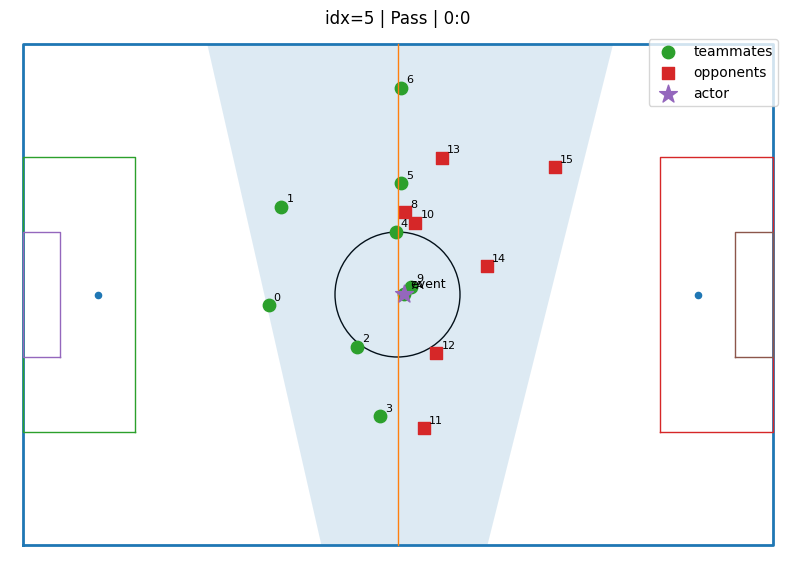

In [3]:
match_id = match_ids_360[0] 
merged = merge_events_and_360(match_id)

with_360 = merged[
    merged["freeze_frame"].apply(lambda x: isinstance(x, list) and len(x) > 0)
]

print(with_360[["index", "type.name", "minute", "second"]].head(10))

event_index = int(with_360.iloc[0]["index"])

row, ff = get_frame_by_event_index(merged, event_index)

plot_single_frame(row, ff)
plt.show()

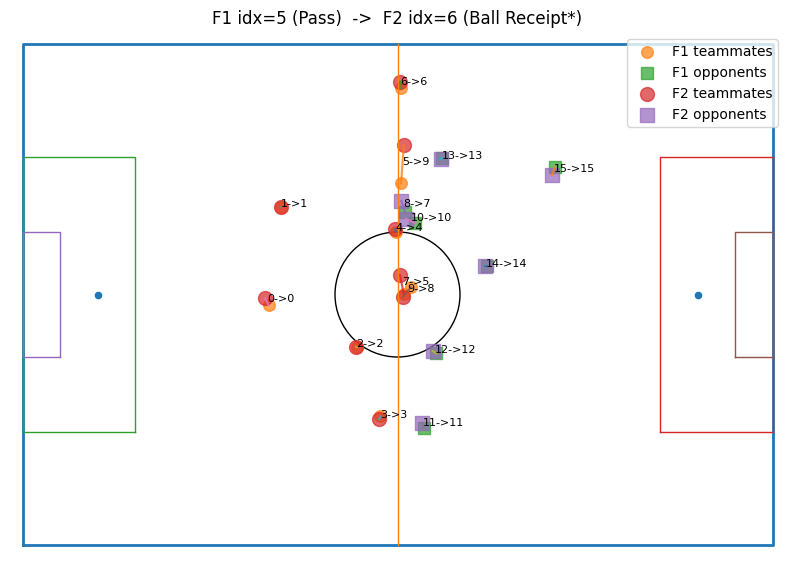

   src_idx  dst_idx      cost      dist  same_team  actor_match  keeper_match  \
0        0        0 -2.761782  1.238218       True         True          True   
1        1        1 -3.862404  0.137596       True         True          True   
2        2        2 -3.836896  0.163104       True         True          True   
3        3        3 -3.478455  0.521545       True         True          True   
4        4        4 -3.629231  0.370769       True         True          True   

       src_x      src_y      dst_x      dst_y  src_teammate  dst_teammate  
0  39.386794  38.273757  38.806643  39.367652          True          True  
1  41.432154  54.068911  41.347127  53.960731          True          True  
2  53.529236  31.590172  53.376262  31.646758          True          True  
3  57.276517  20.489104  57.054758  20.017053          True          True  
4  59.746816  50.076290  59.576600  50.405678          True          True  


In [4]:
_, row1, ff1, row2, ff2, mapping = map_event_to_next_frame(
    match_id=match_id,
    event_index=event_index,
    max_dist=18.0
)

print(mapping.head())

In [5]:
from pathlib import Path
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
from PIL import Image
import copy

PITCH_X = 120.0
PITCH_Y = 80.0

def mirror_xy(x, y, pitch_x=PITCH_X, pitch_y=PITCH_Y):
    return pitch_x - x, pitch_y - y

def mirror_location_list(loc, pitch_x=PITCH_X, pitch_y=PITCH_Y):
    if not isinstance(loc, list) or len(loc) < 2:
        return loc
    out = loc.copy()
    out[0], out[1] = mirror_xy(out[0], out[1], pitch_x, pitch_y)
    return out

def mirror_visible_area(area, pitch_x=PITCH_X, pitch_y=PITCH_Y):
    if area is None or not isinstance(area, list) or len(area) < 2:
        return area
    out = area.copy()
    for i in range(0, len(out), 2):
        out[i] = pitch_x - out[i]
        out[i + 1] = pitch_y - out[i + 1]
    return out

def mirror_freeze_frame(ff, pitch_x=PITCH_X, pitch_y=PITCH_Y):
    if ff is None or not isinstance(ff, list):
        return ff
    out = copy.deepcopy(ff)
    for p in out:
        loc = p.get("location")
        if isinstance(loc, list) and len(loc) >= 2:
            loc[0], loc[1] = mirror_xy(loc[0], loc[1], pitch_x, pitch_y)
    return out

def orient_row_to_reference_team(row, reference_team_id):
    row = row.copy()
    actor_team_id = row.get("team.id")

    if actor_team_id != reference_team_id:
        row["location"] = mirror_location_list(row.get("location"))
        row["visible_area"] = mirror_visible_area(row.get("visible_area"))
        row["freeze_frame"] = mirror_freeze_frame(row.get("freeze_frame"))

        ff = row.get("freeze_frame")
        if isinstance(ff, list):
            ff2 = copy.deepcopy(ff)
            for p in ff2:
                if "teammate" in p:
                    p["teammate"] = not bool(p["teammate"])
            row["freeze_frame"] = ff2

    return row

def normalize_event_row_attacking_lr(row, team_in_possession_col="possession_team.id"):
    """
    Returns a COPY of the row normalized so the possession team attacks left -> right.

    Assumption:
    - StatsBomb 360 already orients each frame so the linked event actor's team attacks left->right.
    - For your own match-world convention, you can decide when to mirror.

    Here, we use a simple flag:
      if row['_needs_mirror'] == True -> mirror row
      else keep as is
    """
    row = row.copy()

    needs_mirror = bool(row.get("_needs_mirror", False))
    if not needs_mirror:
        return row

    row["location"] = mirror_location_list(row.get("location"))
    row["visible_area"] = mirror_visible_area(row.get("visible_area"))
    row["freeze_frame"] = mirror_freeze_frame(row.get("freeze_frame"))
    return row
def resize_to_shape(img_array, target_shape):
    """
    Resize image array to target shape (H, W, C) if needed.
    """
    if img_array.shape == target_shape:
        return img_array

    h, w = target_shape[:2]
    img = Image.fromarray(img_array)
    img = img.resize((w, h))
    return np.array(img)


def interpolate_between_frames(ff1, ff2, mapping, alpha):
    """
    Build an interpolated frame between ff1 and ff2 using mapping.
    alpha in [0, 1]
    """
    ff1 = ff1.reset_index(drop=True).copy()
    ff2 = ff2.reset_index(drop=True).copy()

    matched_src = set(mapping["src_idx"].astype(int).tolist()) if not mapping.empty else set()
    matched_dst = set(mapping["dst_idx"].astype(int).tolist()) if not mapping.empty else set()

    rows = []

    # matched players: interpolate positions
    for _, r in mapping.iterrows():
        sx, sy = r["src_x"], r["src_y"]
        dx, dy = r["dst_x"], r["dst_y"]

        x = (1 - alpha) * sx + alpha * dx
        y = (1 - alpha) * sy + alpha * dy

        src_row = ff1.loc[int(r["src_idx"])]
        dst_row = ff2.loc[int(r["dst_idx"])]

        rows.append({
            "x": x,
            "y": y,
            "teammate": bool(dst_row["teammate"]),
            "actor": bool(dst_row["actor"]) if alpha > 0.5 else bool(src_row["actor"]),
            "keeper": bool(dst_row["keeper"]) if alpha > 0.5 else bool(src_row["keeper"]),
            "alpha": 1.0,
        })

    # unmatched in source: fade out
    for i, row in ff1.iterrows():
        if i in matched_src:
            continue
        rows.append({
            "x": row["x"],
            "y": row["y"],
            "teammate": bool(row["teammate"]),
            "actor": bool(row["actor"]),
            "keeper": bool(row["keeper"]),
            "alpha": max(0.0, 1.0 - alpha),
        })

    # unmatched in destination: fade in
    for j, row in ff2.iterrows():
        if j in matched_dst:
            continue
        rows.append({
            "x": row["x"],
            "y": row["y"],
            "teammate": bool(row["teammate"]),
            "actor": bool(row["actor"]),
            "keeper": bool(row["keeper"]),
            "alpha": max(0.0, alpha),
        })

    return rows


def plot_interpolated_frame(
    interp_players,
    row1,
    row2,
    alpha,
    ax=None,
    show_visible_area=True,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))

    draw_pitch(ax)

    # optionally fade visible area from next frame
    if show_visible_area:
        visible = parse_visible_area(row2.get("visible_area"))
        if visible is not None:
            poly = Polygon(visible, closed=True, alpha=0.10, color="gray")
            ax.add_patch(poly)

    # event location interpolation if both exist
    if isinstance(row1.get("location"), list) and len(row1["location"]) >= 2 and \
       isinstance(row2.get("location"), list) and len(row2["location"]) >= 2:
        ex1, ey1 = row1["location"][:2]
        ex2, ey2 = row2["location"][:2]
        ex = (1 - alpha) * ex1 + alpha * ex2
        ey = (1 - alpha) * ey1 + alpha * ey2
        ax.scatter([ex], [ey], s=140, marker="*", color="gold", edgecolors="black", zorder=7)

    # draw players
    for p in interp_players:
        color = "tab:blue" if p["teammate"] else "tab:red"
        marker = "o" if p["teammate"] else "s"
        size = 80

        if p["actor"]:
            ax.scatter(
                [p["x"]], [p["y"]],
                s=200, marker="*", color="gold",
                edgecolors="black", alpha=max(p["alpha"], 0.2), zorder=8
            )
        elif p["keeper"]:
            ax.scatter(
                [p["x"]], [p["y"]],
                s=140, marker=marker, facecolors="none",
                edgecolors="black", linewidths=2,
                alpha=max(p["alpha"], 0.2), zorder=6
            )
            ax.scatter(
                [p["x"]], [p["y"]],
                s=size, marker=marker, color=color,
                alpha=max(p["alpha"] * 0.6, 0.15), zorder=5
            )
        else:
            ax.scatter(
                [p["x"]], [p["y"]],
                s=size, marker=marker, color=color,
                alpha=max(p["alpha"], 0.15), zorder=5
            )

    ax.set_title(
        f'{row1.get("index")} → {row2.get("index")} | '
        f'blend={alpha:.2f} | '
        f'{row2.get("type.name")}'
    )
    return ax


def make_tracking_gif_interpolated(
    merged,
    start_event_index=None,
    n_frames=8,
    stride=1,
    max_dist=18.0,
    interp_steps=5,   # number of in-between frames per transition
    fps=6,
    out_gif="movement_interpolated.gif",
):
    def has_360(x):
        return isinstance(x, list) and len(x) > 0
    # reference team = actor team of first chosen frame


    available = merged.loc[
        merged["freeze_frame"].apply(has_360), "index"
    ].astype(int).sort_values().tolist()

    if len(available) < 2:
        raise ValueError("Need at least two events with 360 freeze_frame data.")

    if start_event_index is None:
        start_pos = 0
    else:
        if start_event_index in available:
            start_pos = available.index(start_event_index)
        else:
            later = [i for i, idx in enumerate(available) if idx >= start_event_index]
            if not later:
                raise ValueError(f"No 360 frame found at or after event index {start_event_index}")
            start_pos = later[0]

    chosen = available[start_pos:start_pos + n_frames * stride:stride]
    # reference team = actor team of first chosen frame
    first_row, _ = get_frame_by_event_index(merged, chosen[0])
    reference_team_id = first_row.get("team.id")
    if len(chosen) < 2:
        raise ValueError("Chosen sequence is too short to animate.")

    temp_dir = Path("gif_temp_frames_interp")
    temp_dir.mkdir(exist_ok=True)

    rendered_images = []

    for a, b in zip(chosen[:-1], chosen[1:]):
        row1, _ = get_frame_by_event_index(merged, a)
        row2, _ = get_frame_by_event_index(merged, b)

        row1 = orient_row_to_reference_team(row1, reference_team_id)
        row2 = orient_row_to_reference_team(row2, reference_team_id)

        ff1 = freeze_frame_to_df(row1.get("freeze_frame"), event_row=row1)
        ff2 = freeze_frame_to_df(row2.get("freeze_frame"), event_row=row2)

        mapping = map_players_between_frames(
            ff1,
            ff2,
            same_team_only=True,
            max_dist=max_dist,
            actor_bonus=2.0,
            keeper_bonus=2.0,
        )

        # include both endpoints and in-betweens
        alphas = np.linspace(0.0, 1.0, interp_steps + 2)

        for alpha in alphas:
            interp_players = interpolate_between_frames(ff1, ff2, mapping, alpha)

            fig, ax = plt.subplots(figsize=(10, 7))
            plot_interpolated_frame(interp_players, row1, row2, alpha, ax=ax)

            # IMPORTANT: fixed save, no bbox_inches="tight"
            png_path = temp_dir / f"{a}_to_{b}_{alpha:.2f}.png"
            fig.savefig(png_path, dpi=120)
            plt.close(fig)

            img = imageio.imread(png_path)
            rendered_images.append(img)

    # Force all frames to same shape
    target_shape = rendered_images[0].shape
    rendered_images = [resize_to_shape(img, target_shape) for img in rendered_images]

    imageio.mimsave(out_gif, rendered_images, duration=1 / max(fps, 1), loop=0)

    return {
        "gif_path": str(Path(out_gif).resolve()),
        "chosen_event_indices": chosen,
        "n_rendered_frames": len(rendered_images),
        "interp_steps": interp_steps,
    }

In [6]:
match_ids_360 = get_match_ids_with_360()
match_id = match_ids_360[1]

merged = merge_events_and_360(match_id)

result = make_tracking_gif_interpolated(
    merged,
    start_event_index=None,
    n_frames=23,
    stride=1,
    max_dist=18.0,
    interp_steps=6,
    fps=8,
    out_gif="movement_interpolated.gif",
)

print(result)

{'gif_path': '/Users/stefanivchenko/code/exjobb/movement_interpolated.gif', 'chosen_event_indices': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28], 'n_rendered_frames': 176, 'interp_steps': 6}
